In [35]:
# ============================================================
# PROYECTO FINAL ENES
# Estimación de riesgo en la calidad microbiológica del agua en la Ciudad de México mediante un modelo de Machine Learning Supervisado.
# Pedro Pablo Pérez López
# ============================================================

# Librerías utilizadas
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Librerías de Machine Learning utilizadas para el modelo
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import roc_curve


In [3]:
# ------------------------------------------------------------
# Cargar archivo de datos históricos de muestreo
# ------------------------------------------------------------

ruta_excel = r"COLOCAR RUTA DEL DATASET.xlsx"

df = pd.read_excel(ruta_excel)

# Visualizar primeras filas
print(df.head())

# Verificar estructura
print(df.info())

   mes    latitud   longitud   cl  riesgo rango_cloro
0    3  19.299477 -99.063829  0.0       1        Bajo
1    3  19.299477 -99.063829  0.0       1        Bajo
2    3  19.299477 -99.063829  0.0       1        Bajo
3    3  19.314274 -98.993882  0.0       1        Bajo
4    3  19.287606 -99.008520  0.0       1        Bajo
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6774 entries, 0 to 6773
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mes          6774 non-null   int64  
 1   latitud      6774 non-null   float64
 2   longitud     6774 non-null   float64
 3   cl           6774 non-null   float64
 4   riesgo       6774 non-null   int64  
 5   rango_cloro  6774 non-null   object 
dtypes: float64(3), int64(2), object(1)
memory usage: 317.7+ KB
None


In [4]:
# ------------------------------------------------------------
# Cargar archivo shapefile de colonias de la Ciudad de México
# ------------------------------------------------------------

ruta_shp = r"COLOCAR RUTA DEL ARCHIVO SHP.shp"

cdmx = gpd.read_file(ruta_shp)

# Ver columnas disponibles
print(cdmx.columns)

# Ver sistema de referencia espacial
print(cdmx.crs)

Index(['cve_ent', 'entidad', 'cve_alc', 'alc', 'cve_col', 'colonia', 'clasif',
       'geometry'],
      dtype='object')
EPSG:4326


In [5]:
# ------------------------------------------------------------
# Convertir datos a GeoDataFrame utilizando latitud y longitud 
# ------------------------------------------------------------

gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
    crs="EPSG:4326"
)

print(gdf_puntos.head())

   mes    latitud   longitud   cl  riesgo rango_cloro                geometry
0    3  19.299477 -99.063829  0.0       1        Bajo  POINT (-99.064 19.299)
1    3  19.299477 -99.063829  0.0       1        Bajo  POINT (-99.064 19.299)
2    3  19.299477 -99.063829  0.0       1        Bajo  POINT (-99.064 19.299)
3    3  19.314274 -98.993882  0.0       1        Bajo  POINT (-98.994 19.314)
4    3  19.287606 -99.008520  0.0       1        Bajo  POINT (-99.009 19.288)


In [6]:
# ------------------------------------------------------------
# Verificamos que ambos datasets tengan el mismo sistema CRS
# para evitar errores por compatibilidad
# ------------------------------------------------------------

print("CRS puntos:", gdf_puntos.crs)
print("CRS mapa:", cdmx.crs)

CRS puntos: EPSG:4326
CRS mapa: EPSG:4326


In [7]:
# ------------------------------------------------------------
# Identificar puntos fuera del polígono del shapefile para CDMX
# y hacer limpieza de datos (tarda un poquito)
# ------------------------------------------------------------

puntos_fuera = gdf_puntos[~gdf_puntos.within(cdmx.union_all())]

print("Puntos fuera del polígono:", len(puntos_fuera))

Puntos fuera del polígono: 181


In [8]:
# ------------------------------------------------------------
# Eliminar registros con coordenadas fuera de la CDMX
# ------------------------------------------------------------

gdf_puntos = gdf_puntos[gdf_puntos.within(cdmx.union_all())]

print("Total registros limpios:", len(gdf_puntos))

Total registros limpios: 6593


In [9]:
# ------------------------------------------------------------
# Join espacial para asignar colonia a cada punto de muestreo
# ------------------------------------------------------------

gdf_join = gpd.sjoin(gdf_puntos, cdmx, how="left", predicate="within")

print(gdf_join.head())

   mes    latitud   longitud   cl  riesgo rango_cloro                geometry  \
0    3  19.299477 -99.063829  0.0       1        Bajo  POINT (-99.064 19.299)   
1    3  19.299477 -99.063829  0.0       1        Bajo  POINT (-99.064 19.299)   
2    3  19.299477 -99.063829  0.0       1        Bajo  POINT (-99.064 19.299)   
4    3  19.287606 -99.008520  0.0       1        Bajo  POINT (-99.009 19.288)   
5    2  19.401340 -99.118118  1.5       0    Adecuado  POINT (-99.118 19.401)   

   index_right cve_ent           entidad cve_alc        alc  cve_col  \
0          991      09  Ciudad de México     011    Tláhuac  011-043   
1          991      09  Ciudad de México     011    Tláhuac  011-043   
2          991      09  Ciudad de México     011    Tláhuac  011-043   
4         1021      09  Ciudad de México     011    Tláhuac  011-073   
5          445      09  Ciudad de México     006  Iztacalco  006-036   

           colonia   clasif  
0  Granjas Cabrera  Colonia  
1  Granjas Cabrera  

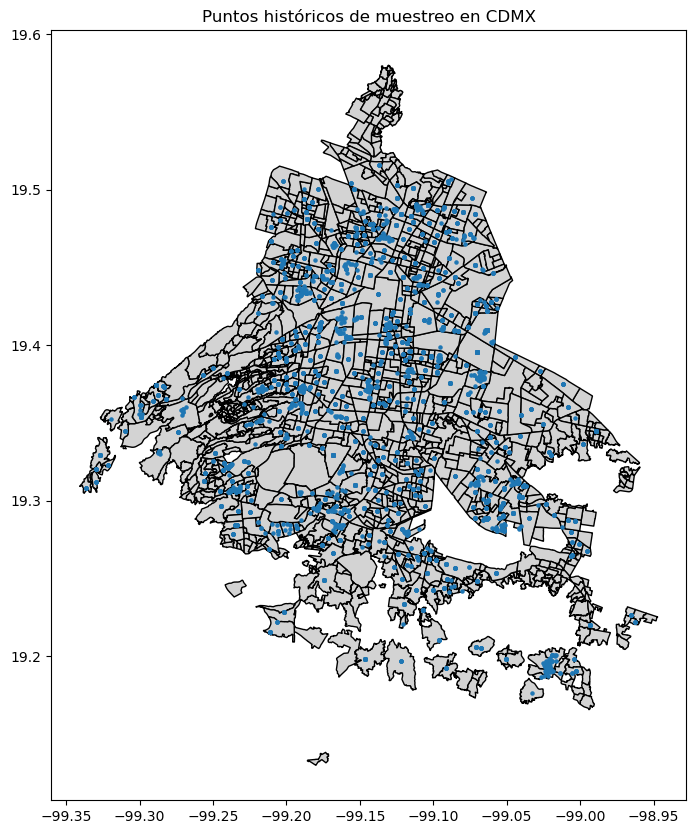

In [42]:
# ------------------------------------------------------------
# Visualizar puntos históricos sobre el mapa de CDMX
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10,10))

cdmx.plot(ax=ax, color="lightgrey", edgecolor="black")
gdf_join.plot(ax=ax, markersize=5)

plt.title("Puntos históricos de muestreo en CDMX")

plt.show()

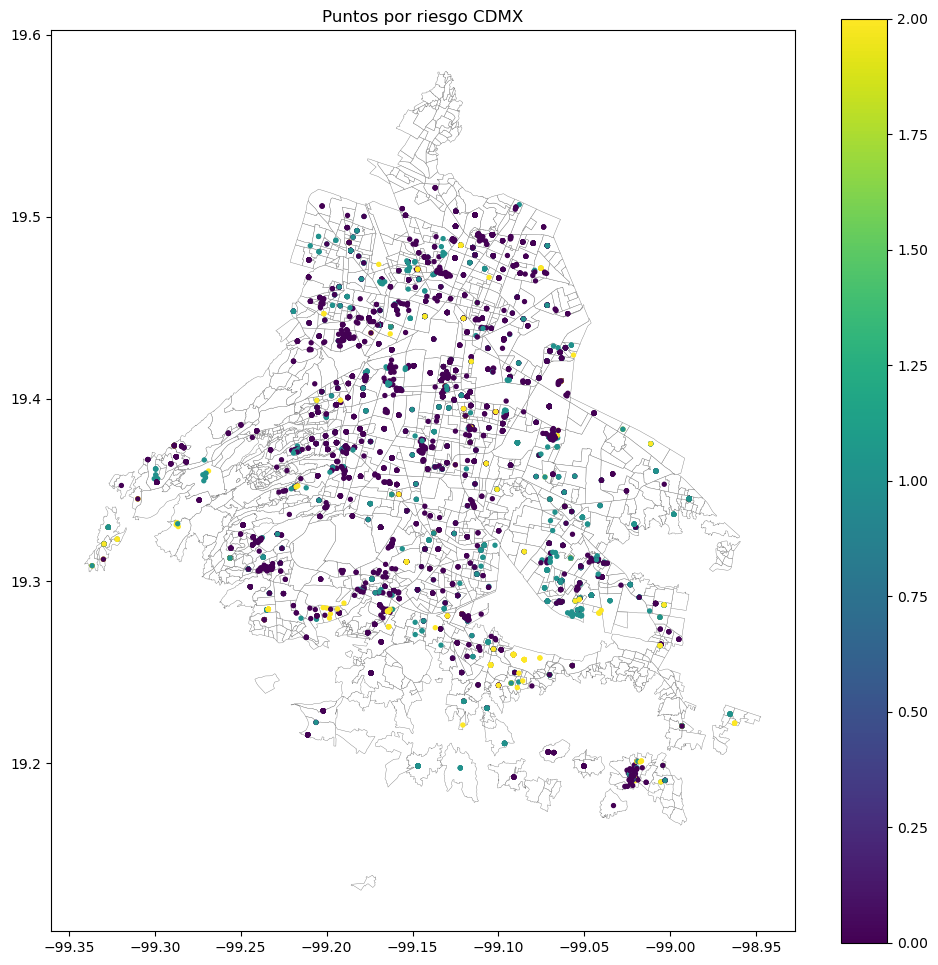

In [43]:
# ------------------------------------------------------------
# Visualizar puntos históricos por riesgo sobre el mapa de CDMX
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12,12))
#Mapa por colonias
cdmx.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.3)

#Puntos por nivel de riesgo
gdf_puntos.plot(
    ax=ax,
    column="riesgo",
    legend=True,
    markersize=8
)
plt.title("Puntos por riesgo CDMX")

plt.show()

In [12]:
# ------------------------------------------------------------
# Calcular número de muestreos por colonia solo para explorar los datos un poco
# ------------------------------------------------------------

conteo_colonia = gdf_join.groupby("colonia").size().reset_index(name="total_muestras")

# Colonias con más muestreos
top_colonias = conteo_colonia.sort_values(by="total_muestras", ascending=False)

print(top_colonias.head(10))

                              colonia  total_muestras
459  San Miguel Teotongo Secc Capilla             119
10                 Agricola Pantitlan             103
289                    Martin Carrera              94
9                   Agricola Oriental              92
338         Pedregal De Santo Domingo              81
265       Leyes De Reforma 3a Seccion              80
301                           Mixcoac              65
201                   Granjas Cabrera              64
308                           Morelos              58
39                 Anahuac Ii Seccion              58


In [13]:
# ------------------------------------------------------------
# Crear variable binaria para el modelo basado en el riesgo
# 0 = sin riesgo
# 1 = riesgo microbiológico
# ------------------------------------------------------------

gdf_join["riesgo_bin"] = gdf_join["riesgo"].apply(lambda x: 0 if x == 0 else 1)

print(gdf_join["riesgo_bin"].value_counts(normalize=True))

riesgo_bin
0    0.682087
1    0.317913
Name: proportion, dtype: float64


In [14]:
# ------------------------------------------------------------
# Seleccionar variables predictoras para el modelo
# ------------------------------------------------------------

X = gdf_join[["latitud","longitud","cl","mes"]]

# Variable objetivo que deamos predecir
y = gdf_join["riesgo_bin"]

In [15]:
# ------------------------------------------------------------
# Dividir dataset para entrenamiento y evaluación
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [16]:
# ------------------------------------------------------------
# Pipeline con imputación de datos faltntes
# y modelo Random Forest
# ------------------------------------------------------------

pipeline = Pipeline([

("imputador", SimpleImputer(strategy="median")),

("modelo", RandomForestClassifier(
n_estimators=200,
random_state=42
))

])

In [17]:
# ------------------------------------------------------------
# Entrenando el modelo 💪🥵
# ------------------------------------------------------------

pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputador', SimpleImputer(strategy='median')),
                ('modelo',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [18]:
# ------------------------------------------------------------
# Generar predicciones con el conjunto de prueba
# ------------------------------------------------------------

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [19]:
# ------------------------------------------------------------
# Generar matriz de confusión para constatar validez de las predicciones
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[789 116]
 [141 273]]


In [20]:
# ------------------------------------------------------------
# Métricas del modelo
# ------------------------------------------------------------

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       905
           1       0.70      0.66      0.68       414

    accuracy                           0.81      1319
   macro avg       0.78      0.77      0.77      1319
weighted avg       0.80      0.81      0.80      1319



In [21]:
# ------------------------------------------------------------
# Calculamos capacidad discriminativa del modelo
# ------------------------------------------------------------

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.8589865748525369


In [22]:
# ------------------------------------------------------------
# Obtenemos importancia de cada variable del modelo
# ------------------------------------------------------------

importancias = pipeline.named_steps["modelo"].feature_importances_

variables = X.columns

for var, imp in zip(variables, importancias):
    print(var, imp)

latitud 0.3340951474340121
longitud 0.34399813074376984
cl 0.17492708044022137
mes 0.14697964138199687


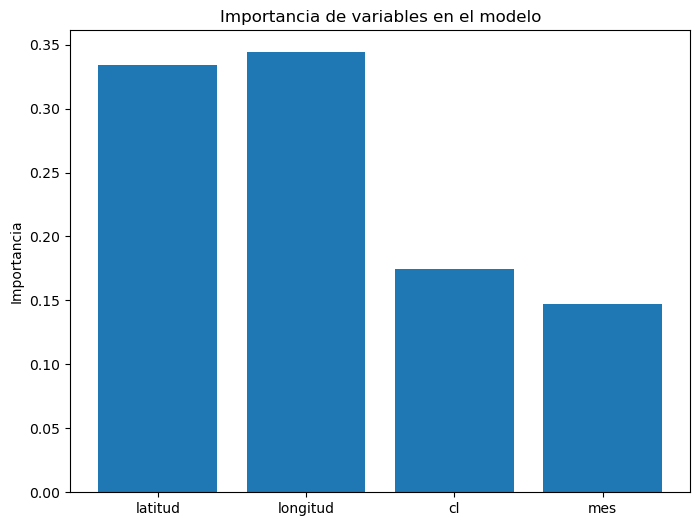

In [23]:
# ------------------------------------------------------------
# Gráfica de importancia de variables na mas pa meter unas graficas
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.bar(variables, importancias)

plt.title("Importancia de variables en el modelo")

plt.ylabel("Importancia")

plt.show()

In [36]:
# ------------------------------------------------------------
# Nos interesa predecir riesgos en puntos futuros de muestreo, sin embargo necesitamos
# definir el threshold que define el umbral de probabilidad a partir del cual el modelo
# decide si un punto se clasifica como “RIESGO” o “SIN RIESGO” asi que
# lo definimos y lo justificamos utilizando la curva ROC
# ------------------------------------------------------------

#Probabilidades de riesgo en el conjunto de prueba
y_prob = pipeline.predict_proba(X_test)[:,1]

#Calcular ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#Calcular índice de Youden
youden = tpr - fpr

#Encontrar mejor umbral
best_index = np.argmax(youden)

best_threshold = thresholds[best_index]

print("Threshold óptimo:", best_threshold)

Threshold óptimo: 0.3353995688360416


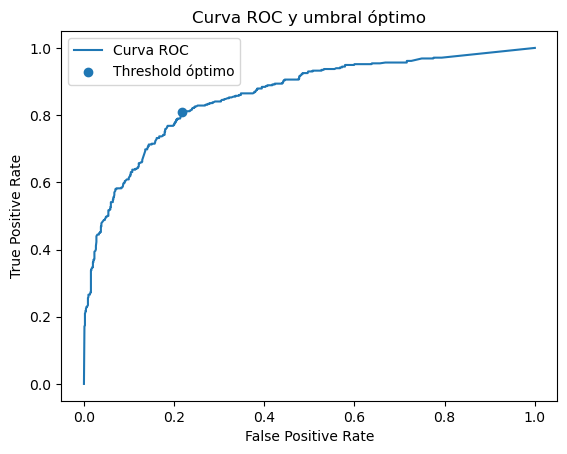

In [40]:
# ------------------------------------------------------------
# Graficamos el punto optimo que nos arroja para el threshold
# ------------------------------------------------------------

plt.figure()

plt.plot(fpr, tpr, label="Curva ROC")

plt.scatter(
    fpr[best_index],
    tpr[best_index],
    label="Threshold óptimo",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC y umbral óptimo")
plt.legend()

plt.show()

In [38]:
# ------------------------------------------------------------
# Ejemplo de predicción de riesgo para un nuevo punto de interes
# Utilizando una función que recibe los datos
# Los nuevos datos de interes pueden carecer de valor de cl o de mes de muestreo
# ------------------------------------------------------------

def predecir_riesgo(latitud, longitud, cl=None, mes=None, threshold=0.3353):

    #Creamos el DataFrame con estructura igual al entrenamiento
    nuevo=pd.DataFrame({
        "latitud": [latitud],
        "longitud": [longitud],
        "cl": [cl],
        "mes": [mes]
    })

    #Obtener probabilidad

    prob=pipeline.predict_proba(nuevo)[0][1]

    #Clasificación con umbral personalizable

    clasificacion=1 if prob >= threshold else 0

    print("Probabilidad de riesgo:", round(prob,4))
    print("Clasificación del punto de interés:", "RIESGO 💀" if clasificacion == 1 else "SIN RIESGO ✅")

    return prob, clasificacion

In [39]:
# ------------------------------------------------------------
# EJEMPLO PARA DETERMINAR RIESGO DE UN PUNTO DE INTERES
# ------------------------------------------------------------

predecir_riesgo(
    latitud=19.35,
    longitud=-99.18,
    cl=0.3,
    mes=7
)

Probabilidad de riesgo: 0.2729
Clasificación del punto de interés: SIN RIESGO ✅


(0.272875, 0)

In [ ]:
# --------------------LEER BIEN----------------------------------
# ¡¡¡¡PASO OPCIONAL PARA CADA USUARIO!!!!
# Guardar modelo para uso posterior (de ser el caso)
# ------------------------------------------------------------

import joblib

joblib.dump(
    pipeline,
    r"RUTA_PARA_GUARDAR_EL_ARCHIVO\modelo_enes_agua.joblib"
)